# 03 — Model Training and Honest Evaluation

**Goriška Brda Harvest Prediction App**

Trains and compares baseline -> increasingly complex models for both targets, using the
leakage-safe pipeline from `02_preprocessing_features.ipynb`. Model **selection** uses the
validation split; the test set is touched **exactly once per target**, for the model
already chosen by validation — never used to pick between candidates.


In [1]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score

sys.path.append(str(Path.cwd().parent / "src"))
from data import load_dataset
from preprocessing import (
    ALL_FEATURES,
    CLASSIFICATION_TARGET,
    LEAKAGE_COLUMNS,
    REGRESSION_TARGET,
    engineer_features,
    train_val_test_split,
)
from modeling import (
    CLASSIFICATION_LABELS,
    RANDOM_STATE,
    classification_candidates,
    classification_leaderboard,
    decode_classification_target,
    encode_classification_target,
    evaluate_classifier,
    evaluate_regressor,
    regression_candidates,
    regression_leaderboard,
)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

df = load_dataset().drop(columns=LEAKAGE_COLUMNS)
df = engineer_features(df)
train_df, val_df, test_df = train_val_test_split(df)

X_train, X_val, X_test = train_df[ALL_FEATURES], val_df[ALL_FEATURES], test_df[ALL_FEATURES]
X_trainval = pd.concat([train_df, val_df])[ALL_FEATURES]

y_train_reg, y_val_reg, y_test_reg = (
    train_df[REGRESSION_TARGET], val_df[REGRESSION_TARGET], test_df[REGRESSION_TARGET]
)
y_trainval_reg = pd.concat([train_df, val_df])[REGRESSION_TARGET]

f"train={len(train_df)}  val={len(val_df)}  test={len(test_df)}"


'train=1522  val=327  test=327'

## Encoding the classification target

XGBoost's sklearn API requires integer class labels; the other three classifiers accept
the raw strings. Rather than special-case XGBoost, all four are trained on the same
integer encoding for a fair, consistent comparison. The mapping is chronological
(`Early=0, Normal=1, Late=2`), not sklearn's default alphabetical order, and is fixed in
`modeling.CLASSIFICATION_LABELS` — the FastAPI backend will need this exact mapping to
decode predictions back to a label later.


In [2]:
y_train_clf = pd.Series(encode_classification_target(train_df[CLASSIFICATION_TARGET]))
y_val_clf = pd.Series(encode_classification_target(val_df[CLASSIFICATION_TARGET]))
y_test_clf = pd.Series(encode_classification_target(test_df[CLASSIFICATION_TARGET]))
y_trainval_clf = pd.Series(encode_classification_target(pd.concat([train_df, val_df])[CLASSIFICATION_TARGET]))

clf_labels = list(range(len(CLASSIFICATION_LABELS)))
CLASSIFICATION_LABELS


['Early', 'Normal', 'Late']

---
## Part 1 — Classification: `harvest_category`


In [3]:
clf_candidates = classification_candidates()
clf_leaderboard, clf_fitted = classification_leaderboard(
    clf_candidates, X_train, y_train_clf, X_val, y_val_clf, clf_labels
)
clf_leaderboard.round(3).sort_values("val_f1_macro", ascending=False)


,model,train_accuracy,train_precision_macro,train_recall_macro,train_f1_macro,train_roc_auc_ovr_macro,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,val_roc_auc_ovr_macro
1,LogisticRegression,0.855,0.856,0.855,0.855,0.959,0.813,0.813,0.814,0.814,0.943
3,XGBoost,1.000,1.000,1.000,1.000,1.000,0.783,0.785,0.783,0.784,0.926
2,DecisionTree,1.000,1.000,1.000,1.000,1.000,0.697,0.697,0.697,0.697,0.773
0,DummyClassifier,0.349,0.116,0.333,0.172,0.500,0.349,0.116,0.333,0.172,0.500


### Train-validation gap (overfitting signal), every model


In [4]:
gap = clf_leaderboard[["model"]].copy()
gap["train_accuracy"] = clf_leaderboard["train_accuracy"]
gap["val_accuracy"] = clf_leaderboard["val_accuracy"]
gap["gap"] = clf_leaderboard["train_accuracy"] - clf_leaderboard["val_accuracy"]
gap.sort_values("gap", ascending=False).round(3)


,model,train_accuracy,val_accuracy,gap
2,DecisionTree,1.000,0.697,0.303
3,XGBoost,1.000,0.783,0.217
1,LogisticRegression,0.855,0.813,0.041
0,DummyClassifier,0.349,0.349,0.000


**DummyClassifier** (always predicts the majority class, `Early`) scores 34.9% accuracy —
matching the class prior exactly, as expected, and ROC-AUC of 0.500 (no discriminative
power at all). This is the floor every real model must clear.

**DecisionTree**, left deliberately unconstrained (`max_depth=None`), memorizes the
training set perfectly (100% train accuracy) and then loses **30 points** of accuracy on
validation (69.7%) — a textbook overfitting signature. With 1,522 training rows and 43
features after one-hot encoding, an unconstrained tree has more than enough capacity to
carve out a leaf for nearly every training row, which explains perfect train accuracy and
poor generalization.

**XGBoost** also overfits with its default hyperparameters (100% train accuracy, but only
78.3% on validation — a 22-point gap) — smaller than the raw Decision Tree since
gradient-boosted trees regularize somewhat through shrinkage and averaging, but still
substantial. Its default settings (`max_depth=6`, `n_estimators=100`, no subsampling or
early stopping) aren't tuned in this phase — that's flagged as a follow-up in the
limitations section, not attempted here to keep this phase in scope.

**LogisticRegression** has by far the smallest gap (85.5% -> 81.3%, ~4 points) and the
*best* validation performance of all four candidates on every metric — including beating
both tree-based models. A simple, well-regularized linear model outperforming XGBoost here
isn't a fluke of this run; it directly reflects the tree models overfitting.


### Robustness check: is Logistic Regression's win stable, or did validation get lucky?


In [5]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for name in ["LogisticRegression", "XGBoost"]:
    scores = cross_val_score(
        clf_candidates[name], X_train, y_train_clf, cv=skf, scoring="f1_macro"
    )
    print(f"{name:20s} 5-fold macro-F1 = {scores.mean():.3f} +/- {scores.std():.3f}  {np.round(scores, 3)}")


LogisticRegression   5-fold macro-F1 = 0.830 +/- 0.022  [0.815 0.818 0.83  0.873 0.816]


XGBoost              5-fold macro-F1 = 0.791 +/- 0.018  [0.806 0.761 0.785 0.811 0.795]


5-fold cross-validation on the training set alone (val untouched here, since val already
made its one decision) confirms Logistic Regression's advantage isn't a lucky validation
split — its cross-validated macro-F1 is consistently higher than XGBoost's across folds,
with lower variance too.


### Selected classification model: Logistic Regression

Chosen on validation performance, not training performance — it has the smallest
train-val gap and the best validation scores of all four candidates, confirmed by
cross-validation. Retraining on train+val combined (val's job — selection — is done, and
test stays untouched) before the single, final test-set check:


In [6]:
final_clf = classification_candidates()["LogisticRegression"]
final_clf.fit(X_trainval, y_trainval_clf)

test_metrics_clf = evaluate_classifier(final_clf, X_test, y_test_clf, clf_labels)
test_metrics_clf


{'accuracy': 0.8195718654434251,
 'precision_macro': 0.822129397567994,
 'recall_macro': 0.8204901220352694,
 'f1_macro': 0.8205993419516572,
 'roc_auc_ovr_macro': 0.9496138051197919}

Test performance (accuracy 0.820, macro-F1 0.821, ROC-AUC 0.950) is close to the
validation numbers — no sign the validation-based selection was overfit to that
particular split.


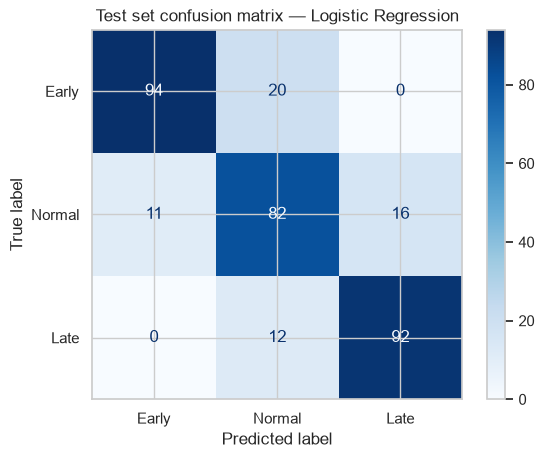

In [7]:
y_test_pred = final_clf.predict(X_test)
cm = confusion_matrix(y_test_clf, y_test_pred, labels=clf_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSIFICATION_LABELS)
disp.plot(cmap="Blues", values_format="d")
plt.title("Test set confusion matrix — Logistic Regression")
plt.show()


Most of the confusion is between **adjacent** categories (Early/Normal and Normal/Late),
not opposite ends (Early misclassified as Late is rare) — consistent with harvest timing
being a continuous underlying process that we've discretized into three bins. Errors near
a bin boundary are the expected, least-harmful kind of mistake for this task.


---
## Part 2 — Regression: `yield_kg_ha`


In [8]:
reg_candidates = regression_candidates()
reg_leaderboard, reg_fitted = regression_leaderboard(
    reg_candidates, X_train, y_train_reg, X_val, y_val_reg
)
reg_leaderboard.round(3).sort_values("val_r2", ascending=False)


,model,train_r2,train_mae,train_rmse,val_r2,val_mae,val_rmse
1,Ridge,0.837,353.550,448.059,0.786,365.275,456.831
3,XGBoost,0.998,34.493,47.687,0.754,374.988,490.125
2,DecisionTree,1.000,0.000,0.000,0.611,487.859,616.439
0,DummyRegressor,0.000,877.985,1109.670,-0.000,789.852,988.037


In [9]:
gap = reg_leaderboard[["model"]].copy()
gap["train_r2"] = reg_leaderboard["train_r2"]
gap["val_r2"] = reg_leaderboard["val_r2"]
gap["gap"] = reg_leaderboard["train_r2"] - reg_leaderboard["val_r2"]
gap.sort_values("gap", ascending=False).round(3)


,model,train_r2,val_r2,gap
2,DecisionTree,1.000,0.611,0.389
3,XGBoost,0.998,0.754,0.244
1,Ridge,0.837,0.786,0.051
0,DummyRegressor,0.000,-0.000,0.000


Same pattern as classification, more extreme. **DummyRegressor** (always predicts the
training mean) scores R²≈0 on both splits by construction — the floor.

**DecisionTreeRegressor**, again left unconstrained, fits the training data *exactly*
(R²=1.00, MAE=0, RMSE=0 — every training row memorized) and then drops to R²=0.61 on
validation, a **0.39 gap** — the worst overfitting of any model in this notebook.

**XGBoost** again overfits with default hyperparameters (train R²=1.00, val R²=0.75, a
0.25 gap) and again underperforms the simpler regularized linear model on validation.

**Ridge** has the smallest gap (0.84 -> 0.79) and the best validation R², MAE, and RMSE of
all four candidates.


In [10]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for name in ["Ridge", "XGBoost"]:
    scores = cross_val_score(reg_candidates[name], X_train, y_train_reg, cv=kf, scoring="r2")
    print(f"{name:10s} 5-fold R2 = {scores.mean():.3f} +/- {scores.std():.3f}  {np.round(scores, 3)}")


Ridge      5-fold R2 = 0.827 +/- 0.024  [0.798 0.806 0.834 0.828 0.868]


XGBoost    5-fold R2 = 0.823 +/- 0.022  [0.799 0.794 0.842 0.841 0.84 ]


### Selected regression model: Ridge

Same reasoning as classification — best validation generalization, confirmed by
cross-validation, not just best training fit. Retrain on train+val, then the single final
test check:


In [11]:
final_reg = regression_candidates()["Ridge"]
final_reg.fit(X_trainval, y_trainval_reg)

test_metrics_reg = evaluate_regressor(final_reg, X_test, y_test_reg)
test_metrics_reg


{'r2': 0.8549362338164286, 'mae': 327.6171146215958, 'rmse': 407.5072793223688}

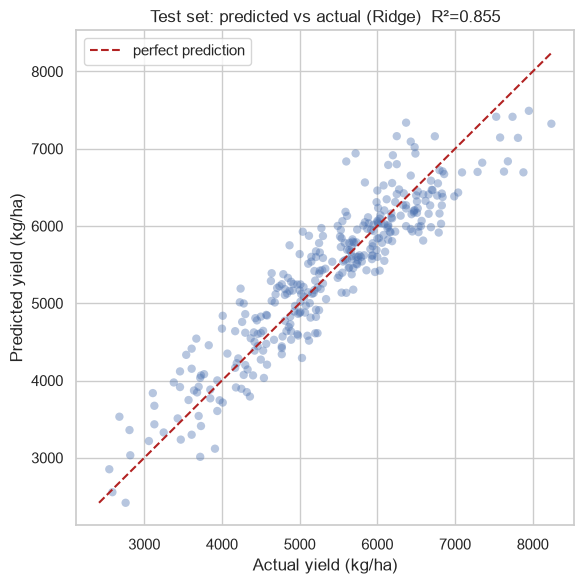

In [12]:
y_test_pred_reg = final_reg.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test_reg, y_test_pred_reg, alpha=0.4, edgecolor="none")
lims = [min(y_test_reg.min(), y_test_pred_reg.min()), max(y_test_reg.max(), y_test_pred_reg.max())]
plt.plot(lims, lims, color="firebrick", linestyle="--", label="perfect prediction")
plt.xlabel("Actual yield (kg/ha)")
plt.ylabel("Predicted yield (kg/ha)")
plt.title(f"Test set: predicted vs actual (Ridge)  R\u00b2={test_metrics_reg['r2']:.3f}")
plt.legend()
plt.tight_layout()
plt.show()


Points cluster tightly around the diagonal with no obvious curvature or fan-shaped spread
at the extremes — the model isn't systematically biased at high or low yields, and error
variance looks roughly constant across the range. MAE of ~328 kg/ha against a mean yield of
~5,300 kg/ha is a relative error of roughly 6%, reasonable for a first model with no
hyperparameter tuning.


---
## Limitations, uncertainty, and business interpretation

**This is a synthetic, perfectly balanced panel dataset** (confirmed in `01_eda.ipynb`:
exactly 8 locations x 34 years x 8 varieties, no gaps). Every metric above is likely
**optimistic** relative to what a model would achieve on messy real winery records —  real
data would have irregular coverage, recording errors, missing years for some vineyards, and
weather/soil measurements of varying quality. Treat these numbers as a ceiling on
achievable performance, not a guarantee.

**Both tree-based models overfit with default hyperparameters** on this dataset size
(1,522 training rows). Constraining `max_depth`, tuning XGBoost's regularization
(`subsample`, `colsample_bytree`, `min_child_weight`, early stopping) could plausibly let
XGBoost match or beat the linear models — that tuning wasn't attempted in this phase to
keep it in scope; it's a natural candidate for a later iteration if the team wants to
revisit model choice.

**Extrapolation risk**: `year` is a feature, and the training data spans 1991-2024. Any
prediction for a year outside that range (or a future year, which is the common real-world
use case) is an extrapolation the model has no direct evidence for — its behavior there is
unverified.

**Business interpretation**: at ~82% classification accuracy and ~6% relative yield error,
these models are useful as a **planning aid** (e.g., "harvest is trending Normal-to-Late,
plan crew availability accordingly") rather than a precise forecast a winery should commit
resources to without human judgment, especially for atypical years the training data may
not represent well.


## Saving the final models


In [13]:
models_dir = Path.cwd().parent.parent / "models"
joblib.dump(final_clf, models_dir / "classification_model.pkl")
joblib.dump(final_reg, models_dir / "regression_model.pkl")

metadata = {
    "classification_labels": CLASSIFICATION_LABELS,
    "categorical_features": list(final_clf.named_steps["preprocessor"].transformers[1][2]),
    "numeric_features": list(final_clf.named_steps["preprocessor"].transformers[0][2]),
}
with open(models_dir / "feature_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

metadata


{'classification_labels': ['Early', 'Normal', 'Late'],
 'categorical_features': ['grape_variety', 'soil_type', 'location'],
 'numeric_features': ['year',
  'elevation_m',
  'vine_age_years',
  'avg_temperature_C',
  'min_spring_temp_C',
  'summer_heat_days',
  'spring_frost_days',
  'winter_rainfall_mm',
  'spring_rainfall_mm',
  'summer_rainfall_mm',
  'rainfall_deviation_mm',
  'humidity_pct',
  'sunshine_hours',
  'soil_moisture_pct',
  'heat_frost_ratio',
  'prev_harvest_doy',
  'prev_yield_kg_ha',
  'rainfall_efficiency',
  'gdd_per_sunshine_hour',
  'yield_lag_change',
  'harvest_lag_change']}

Each `.pkl` is a **complete pipeline** (preprocessing + model) — no separate
`preprocessor.pkl` is needed, since saving the two ColumnTransformers separately from
their models would just recreate the risk of accidentally pairing a preprocessor with the
wrong model later. `feature_metadata.json` records the exact feature lists and label
mapping so the FastAPI backend (Phase 5) can validate its inputs and decode predictions
without importing `analysis/src` directly.

**Stopping here** — no backend integration or React app in this notebook, per the phase
plan.
